# Assignment 2 
**Name**: Tianyang Chen<br>
**Course**: Machine Learning Foundations 2025<br>
**Date**: March 28, 2025  

**GitHub Repository**: <br>

- **SSH**: git@github.com:Julia047/ML-fundamentals-2025.git

- **HTTPS**: https://github.com/Julia047/ML-fundamentals-2025.git

## **Task 1: ExploratoryDataAnalysis (EDA)**  # 

### **1.1 Loading Dataset** ##

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

In [2]:
# File path
file_path = "D:/交流交换/MLF/assignment_2/bike+sharing+dataset/hour.csv"
# Load the dataset
df = pd.read_csv(file_path)

### **1.2 Explore Data Structure** ###

#### **1.2.1 Overview of first 5 rows** ###

In [3]:
print(df.head())

   instant    dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011/1/1       1   0     1   0        0        6           0   
1        2  2011/1/1       1   0     1   1        0        6           0   
2        3  2011/1/1       1   0     1   2        0        6           0   
3        4  2011/1/1       1   0     1   3        0        6           0   
4        5  2011/1/1       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


#### **1.2.2 Feature types** ###

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB
None


### **Key Observations:**

- There are a total of **17379 entries (hourly records)** and **16 columns (features)** recorded in the Bike Sharing Dataset.
- **No missing values** in any column.
- The dataset includes both **numerical and categorical** features.


####  **Temporal Features**
- **`dteday`** (date)  
- **`yr`** (year: `0 = 2011`, `1 = 2012`)  
- **`mnth`** (month)  
- **`hr`** (hour of the day)  
- **`weekday`** (day of the week)  
- **`workingday`** (whether it's a working day)  
- **`holiday`** (whether it's a holiday)  

#### **Weather Conditions**
- **`temp`** (normalized temperature)  
- **`atemp`** (normalized feeling temperature)  
- **`hum`** (humidity)  
- **`windspeed`** (wind speed)  

#### **Bike Rental Information**
- **`casual`** (number of casual users)  
- **`registered`** (number of registered users)  
- **`cnt`** (total rentals)  


### **1.3 Target variable (cnt) distribution** ###

Plot the distribution histogram

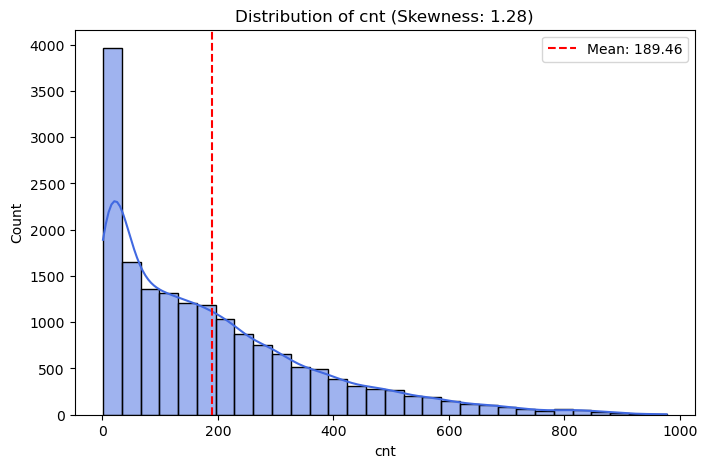

Skewness of cnt: 1.28


In [5]:
skewness_value = skew(df['cnt'])

# plot distribution chart
plt.figure(figsize=(8, 5))
sns.histplot(df['cnt'], bins=30, kde=True, color='royalblue')
plt.axvline(np.mean(df['cnt']), color='red', linestyle='dashed', label=f"Mean: {np.mean(df['cnt']):.2f}")
plt.title(f"Distribution of cnt (Skewness: {skewness_value:.2f})")
plt.legend()
plt.show()

print(f"Skewness of cnt: {skewness_value:.2f}")

#### **Observations**

- **Right-Skewed Distribution**: **Skewness = 1.28**, indicating that `cnt` follows a **right-skewed (positively skewed) distribution**.
- **Peaks near 0**: suggesting that bike rental are low during most of the periods (e.g., late-night hours).
- **Long right tail**: there are a few high values, indicating **occasional peak rental periods**.  

#### **Skewness Correction**

Since `cnt` is skewed, a transformation such as **log(cnt + 1)** or **sqrt(cnt)** can be applied to reduce skewness.  

- **Linear regression** assumes that the error terms follow a **normal distribution**. If cnt is highly right-skewed, directly modeling it may lead to non-normal residuals and heteroscedasticity, which can **affect the stability** of the regression model.

- For **Random Forest and Gradient Boosting**, a transformation is not strictly necessary, but it is still applied to **maintain consistency across models**.

- We first applied **log transformation**, and the skewness reduced from **1.28 to -0.82**.

- However, the **square root** transformation resulted in a **lower skewness of 0.29**; we finally **choose sqrt** transformation as it is more closer to 0.

In [6]:
df["cnt"] = np.sqrt(df["cnt"])

Skewness check after correction.

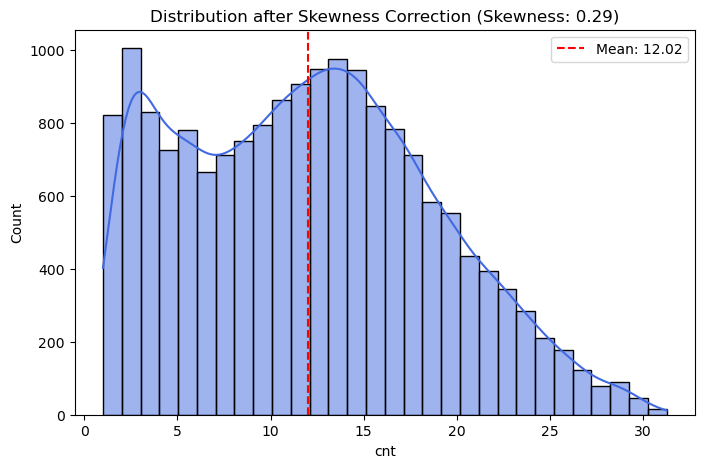

Skewness of cnt: 0.29


In [7]:
skewness_value = skew(df['cnt'])

# plot distribution chart
plt.figure(figsize=(8, 5))
sns.histplot(df['cnt'], bins=30, kde=True, color='royalblue')
plt.axvline(np.mean(df['cnt']), color='red', linestyle='dashed', label=f"Mean: {np.mean(df['cnt']):.2f}")
plt.title(f"Distribution after Skewness Correction (Skewness: {skewness_value:.2f})")
plt.legend()
plt.show()

print(f"Skewness of cnt: {skewness_value:.2f}")

### **1.4 Analytical Exploration of Factors Influencing Bike Rentals** ###

#### **1.4.1 Impact of Temporal Features on Bike Rentals** ###

- We use **line plot** to analyze temporal features as it can effectively **illustrate trends and seasonal patterns over time**.
- To examine how cnt is influenced by time, we **use the mean rather than the sum** as it helps **smooth out extreme values**, providing a clearer representation of typical rental patterns throughout different periods.



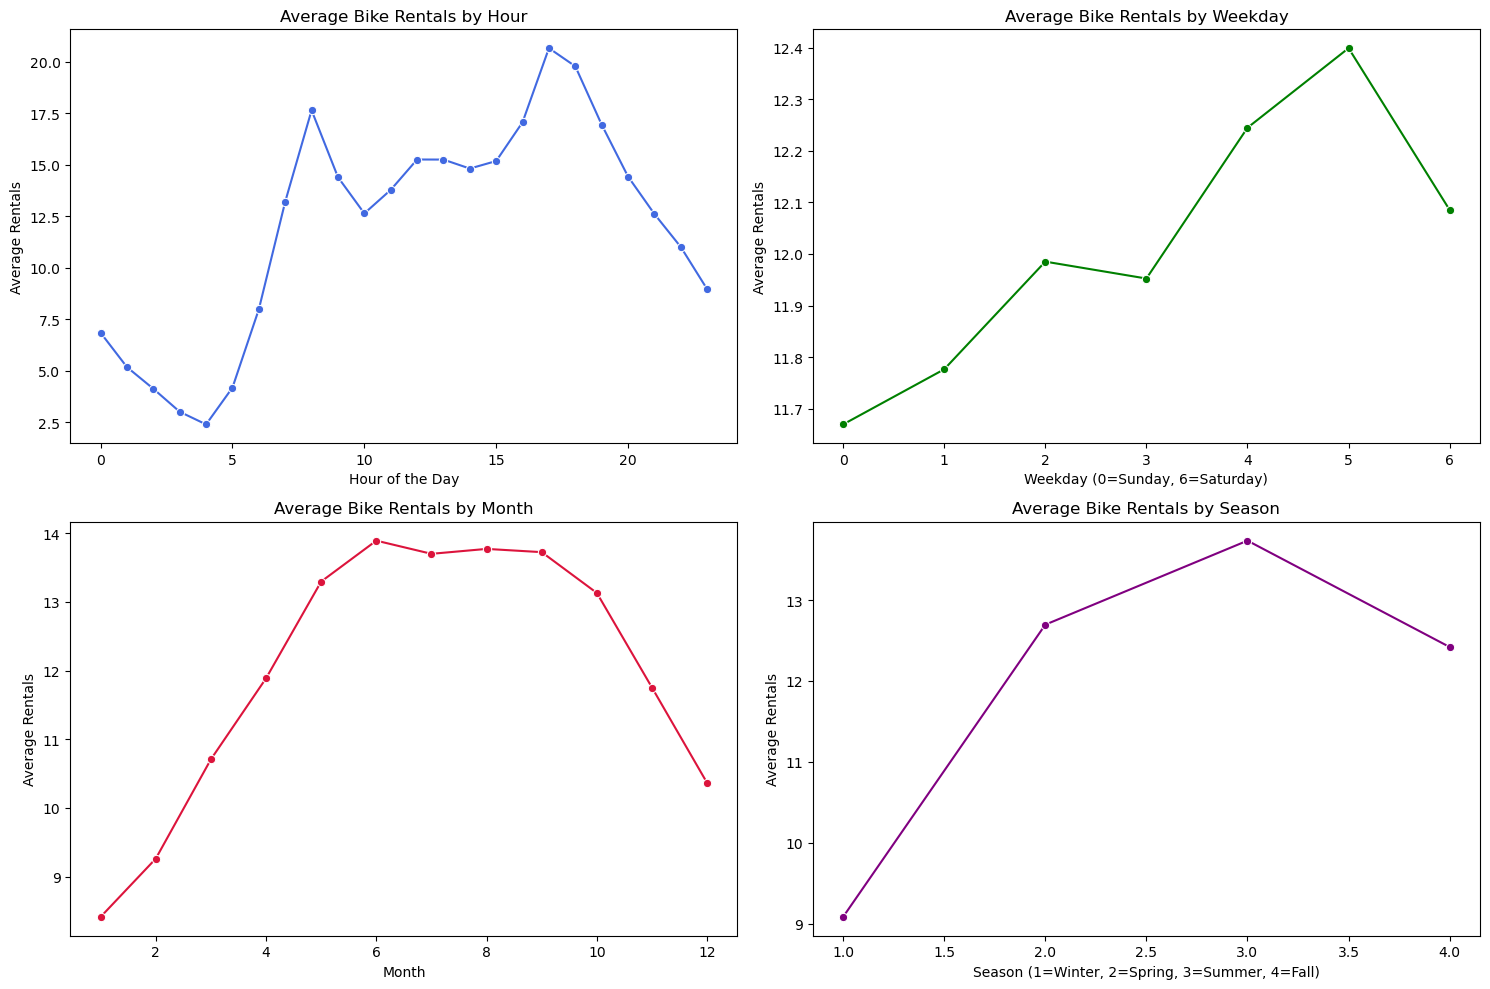

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Average Bike Rentals by Hour
sns.lineplot(ax=axes[0, 0], x="hr", y="cnt", data=df, errorbar=None, marker="o", color="royalblue", estimator="mean")
axes[0, 0].set_title("Average Bike Rentals by Hour")
axes[0, 0].set_xlabel("Hour of the Day")
axes[0, 0].set_ylabel("Average Rentals")

# Average Bike Rentals by Weekday
sns.lineplot(ax=axes[0, 1], x="weekday", y="cnt", data=df, errorbar=None, marker="o", color="green", estimator="mean")
axes[0, 1].set_title("Average Bike Rentals by Weekday")
axes[0, 1].set_xlabel("Weekday (0=Sunday, 6=Saturday)")
axes[0, 1].set_ylabel("Average Rentals")

# Average Bike Rentals by Month
sns.lineplot(ax=axes[1, 0], x="mnth", y="cnt", data=df, errorbar=None, marker="o", color="crimson", estimator="mean")
axes[1, 0].set_title("Average Bike Rentals by Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Average Rentals")

# Average Bike Rentals by Season
sns.lineplot(ax=axes[1, 1], x="season", y="cnt", data=df, errorbar=None, marker="o", color="purple", estimator="mean")
axes[1, 1].set_title("Average Bike Rentals by Season")
axes[1, 1].set_xlabel("Season (1=Winter, 2=Spring, 3=Summer, 4=Fall)")
axes[1, 1].set_ylabel("Average Rentals")

plt.tight_layout()  
plt.show()

### **Observations**
**Hourly Bike Rentals**
- Two **peaks**: one around 8 AM and another at 5-6 PM, corresponding to typical **commuting hours**.
- Rentals are **lowest** during the early **morning** hours (midnight to 5 AM).
- A steady **decline** is observed after the **evening** peak.

**Bike Rentals by Weekday**
- Rentals gradually **increase** from Sunday (0) to Friday (5), peaking on Fridays and Saturdays.

**Bike Rentals by Month** 
- Bike usage steadily rises from January (1) to June (6), **peaking in the summer months** (June - September).
- Rentals **decline after October** (10), likely due to colder weather conditions.

**Bike Rentals by Season** 
- **Spring and Summer** (Seasons 2 & 3) show the **highest** average rentals.
- **Winter** (Season 1) has the **lowest** bike usage, suggesting that cold weather negatively affects ridership.


#### **1.4.2 Impact of Binary Features on Bike Rentals** ###

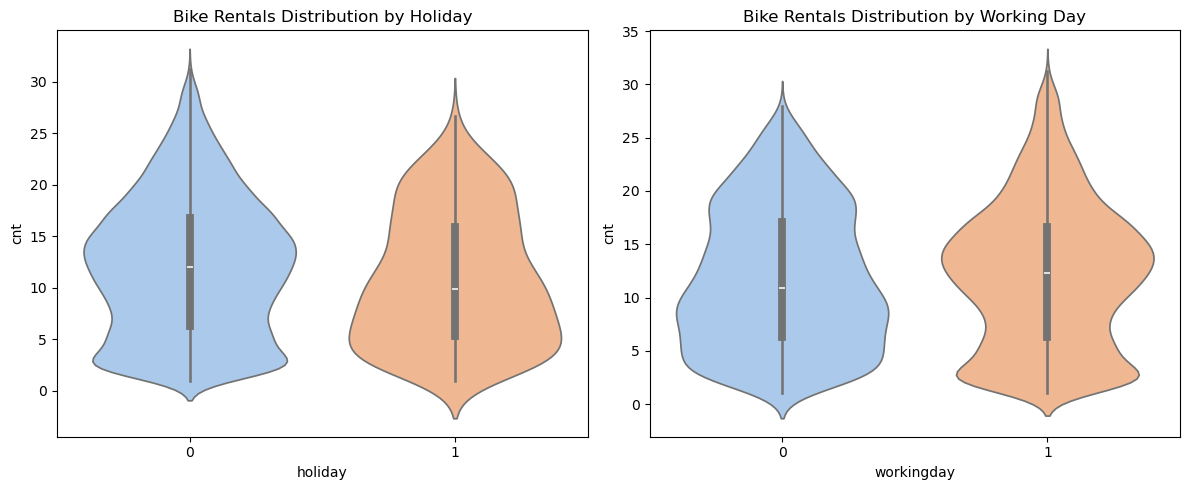

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# violin plot - Holiday
sns.violinplot(x="holiday", y="cnt", data=df, ax=axes[0], hue="holiday", palette="pastel", legend=False)
axes[0].set_title("Bike Rentals Distribution by Holiday")

# violin plot - Working Day
sns.violinplot(x="workingday", y="cnt", data=df, ax=axes[1], hue="workingday", palette="pastel", legend=False)
axes[1].set_title("Bike Rentals Distribution by Working Day")

plt.tight_layout()
plt.show()

### **Observations**
**1. Bike Rentals by Holiday**
- The shape and spread of rentals on holidays (1) and non-holidays (0) are **similar**.

- However, **non-holidays** show a **slightly higher median** and a **broader spread** in upper values, suggesting that there are more bike rentals on non-holidays, possibly due to commuting.

**2. Bike Rentals by Working Day**
- Rentals are more **concentrated and higher** on **working days** (1) compared to non-working days (0).

- This supports the idea that bike rentals are driven more by daily commutes than by leisure activities, with people **using bikes more** consistently during **workdays**.


### **Statistical Analysis of Binary Features on cnt**
We further performed **Mann-Whitney U tests** to examine whether the binary variables holiday and workingday significantly influence the total bike rentals (cnt).

In [10]:
from scipy.stats import mannwhitneyu
# group data
holiday_cnt = df[df["holiday"] == 1]["cnt"]
non_holiday_cnt = df[df["holiday"] == 0]["cnt"]

workingday_cnt = df[df["workingday"] == 1]["cnt"]
non_workingday_cnt = df[df["workingday"] == 0]["cnt"]

# Mann-Whitney U test - Holiday vs. Non-Holiday
u_stat_holiday, p_val_holiday = mannwhitneyu(holiday_cnt, non_holiday_cnt, alternative="two-sided")
print(f"Holiday vs. Non-Holiday (Mann-Whitney U): U-statistic = {u_stat_holiday:.4f}, p-value = {p_val_holiday:.4f}")

# Mann-Whitney U test - Working Day vs. Non-Working Day
u_stat_workingday, p_val_workingday = mannwhitneyu(workingday_cnt, non_workingday_cnt, alternative="two-sided")
print(f"Working Day vs. Non-Working Day (Mann-Whitney U): U-statistic = {u_stat_workingday:.4f}, p-value = {p_val_workingday:.4f}")

Holiday vs. Non-Holiday (Mann-Whitney U): U-statistic = 3789427.5000, p-value = 0.0001
Working Day vs. Non-Working Day (Mann-Whitney U): U-statistic = 33565313.0000, p-value = 0.0056


Both holidays and working days **significantly impact bike rental patterns**, as indicated by the **low p-values (< 0.05)**.

#### **1.4.3 Impact of Weather-Related Features on Bike Rentals** ###

- We use **scatter plots** to visualize the relationship between **continuous weather variables** (temp, atemp, hum, windspeed) and bike rentals as it can effectively **capture the spread and density** of data points.

- For weathersit (categorical variable), we used **line plot** instead of a scatter plot. 

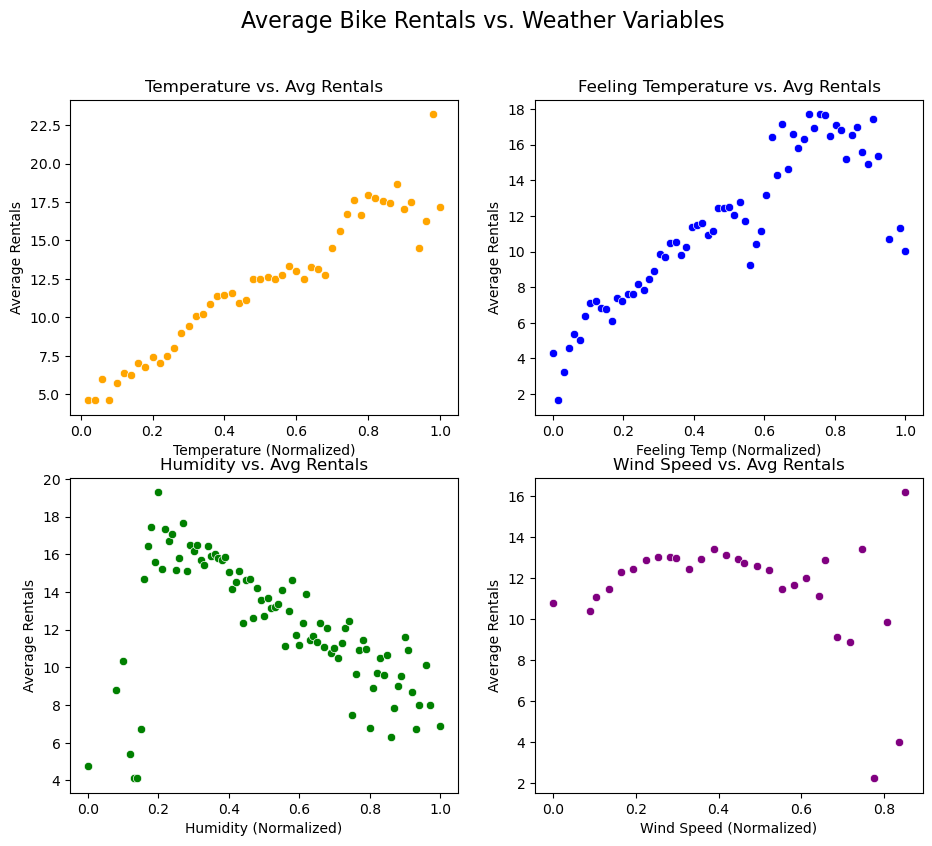

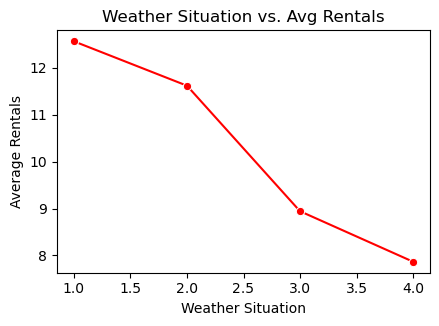

In [11]:
# Calculate the average rental number of each variable
temp_mean = df.groupby("temp", as_index=False)["cnt"].mean()
atemp_mean = df.groupby("atemp", as_index=False)["cnt"].mean()
hum_mean = df.groupby("hum", as_index=False)["cnt"].mean()
windspeed_mean = df.groupby("windspeed", as_index=False)["cnt"].mean()
weathersit_mean = df.groupby("weathersit", as_index=False)["cnt"].mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
fig.suptitle("Average Bike Rentals vs. Weather Variables", fontsize=16)

# scatter plot for weather features
sns.scatterplot(x="temp", y="cnt", data=temp_mean, color="orange", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Temperature vs. Avg Rentals")
axes[0, 0].set_xlabel("Temperature (Normalized)")
axes[0, 0].set_ylabel("Average Rentals")

sns.scatterplot(x="atemp", y="cnt", data=atemp_mean, color="blue", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Feeling Temperature vs. Avg Rentals")
axes[0, 1].set_xlabel("Feeling Temp (Normalized)")
axes[0, 1].set_ylabel("Average Rentals")

sns.scatterplot(x="hum", y="cnt", data=hum_mean, color="green", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Humidity vs. Avg Rentals")
axes[1, 0].set_xlabel("Humidity (Normalized)")
axes[1, 0].set_ylabel("Average Rentals")

sns.scatterplot(x="windspeed", y="cnt", data=windspeed_mean, color="purple", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Wind Speed vs. Avg Rentals")
axes[1, 1].set_xlabel("Wind Speed (Normalized)")
axes[1, 1].set_ylabel("Average Rentals")

# line plot of weathersit
plt.figure(figsize=(4.5, 3.5))
sns.lineplot(x="weathersit", y="cnt", data=weathersit_mean, color="red", marker="o")
plt.title("Weather Situation vs. Avg Rentals")
plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### **Observations**
**1. Temperature vs. Average Rentals**
- Overall, there is a **positive correlation** between temperature and bike rentals.

- However, there is a **turning point** around 0.75 - 0.8 (**30°C**), which means the bike rentals slightly drop when the temperature is extremely high.

**2. Feeling Temperature vs. Average Rentals**

- Similar to actual temperature, the feeling temperature shows a **strong positive trend** with bike rentals (And a turning pt at extremely hot weather).
  
**3. Humidity vs. Average Rentals**

- Exhibit a **negative trend**, meaning **higher humidity** is associated with **fewer bike rentals**.

**4. Wind Speed vs. Average Rentals**

- The relationship between wind speed and rentals appears **nonlinear**.

- This suggests that mild wind may not affect biking much; we may need a statistic test to examine it further.

**5. Weather Situation vs. Average Rentals**

- The downward trend suggests that as **weather worsens**, people are significantly **less likely** to rent bikes..

### **1.5 Exploration of interaction effect**

We use 3D plot to explore interaction effect of temp × humidity.

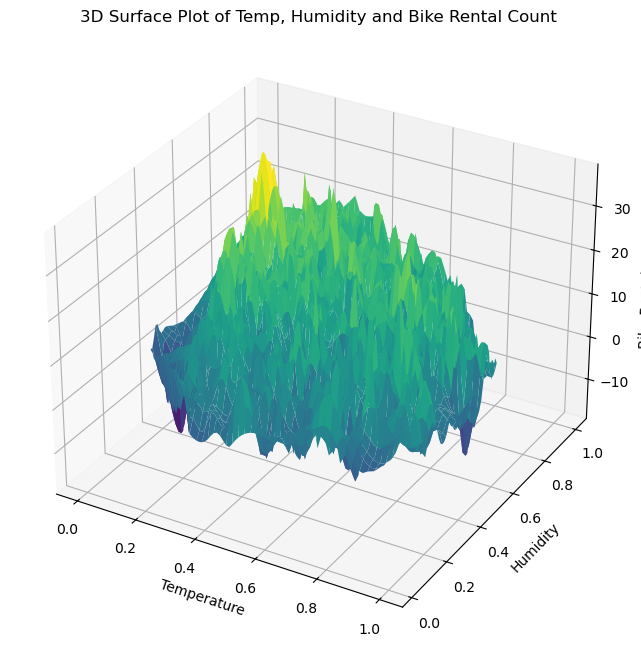

In [12]:
from mpl_toolkits.mplot3d import Axes3D

y = df['temp']  
x = df['hum']  
z = df['cnt']  

x_grid, y_grid = np.meshgrid(np.linspace(x.min(), x.max(), 100), 
                             np.linspace(y.min(), y.max(), 100))

from scipy.interpolate import griddata
z_grid = griddata((x, y), z, (x_grid, y_grid), method='cubic')

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis')

ax.set_xlabel('Temperature')
ax.set_ylabel('Humidity')
ax.set_zlabel('Bike Rental Count')
ax.set_title('3D Surface Plot of Temp, Humidity and Bike Rental Count')

plt.show()

- The surface plot exhibits a **rugged shape**, which indicates the presence of **interaction effects** between temperature and humidity on bike rental count.

- Specifically, the plot shows **local extrema**, suggesting the relationship between temperature and bike rental count is **not purely additive**, but rather **dependent on the combined effect** of both temperature and humidity.
- We may consider adding the interaction term in feature engineering.

#### **1.6 Removing Unnecessary Features** ###

#### **Following irrelevant features were moved for several reasons**:
- `instant`: An index column that is unnecessary for analysis.
- `dteday`: The date column is **unnecessary** as season, month, and weekday already contain time information.
- `casual` & `registered`: These two columns sum up to cnt (total rentals). We remove them to avoid **data leakage**.

In [13]:
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

Remaining features

In [14]:
df.columns

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

## **Task 2: Data Splitting**

- Since the **task** is to predict hourly bike rental counts using **environmental and temporal features**, maintaining a strict chronological order is unnecessary. Instead, a **random split** is applied while **preserving the diversity of different time periods** to ensure the data remains representative of various conditions.

- To **preserve the temporal order**, we randomly partition the data **within each hour** to ensure that different time periods (hours, seasons, and months) are evenly represented in training, validation, and test sets.

- As consecutive data points do not influence each other, random splitting within each hour does **not induce data leakage**.

#### **Splitting Strategy**

1. **Randomly shuffle** the dataset to remove any inherent order.

2. **Stratifying by hour**: ensuring each dataset contains a diverse mix of different seasons, weekdays, and weather conditions, improving the model’s ability to generalize.

3. Stratified random sampling: Within each hour, **randomly split the data into training (60%), validation (20%), and test (20%)** sets to ensure a well-balanced distribution.

In [15]:
from sklearn.model_selection import train_test_split 

X = df.drop(['cnt'], axis=1)  
y = df['cnt']  # target variable

# Stratify by hourly to ensure an even distribution of data for all hours
df['hr_bins'] = pd.cut(df['hr'], bins=6, labels=False)  # Divide the 24 hours into 6 groups.

# randomly shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# 60%-20%-20% split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=df['hr_bins'], random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=df.loc[X_temp.index, 'hr_bins'], random_state=42)

df.drop(columns=['hr_bins'], inplace=True)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Training set size: 10427
Validation set size: 3476
Test set size: 3476


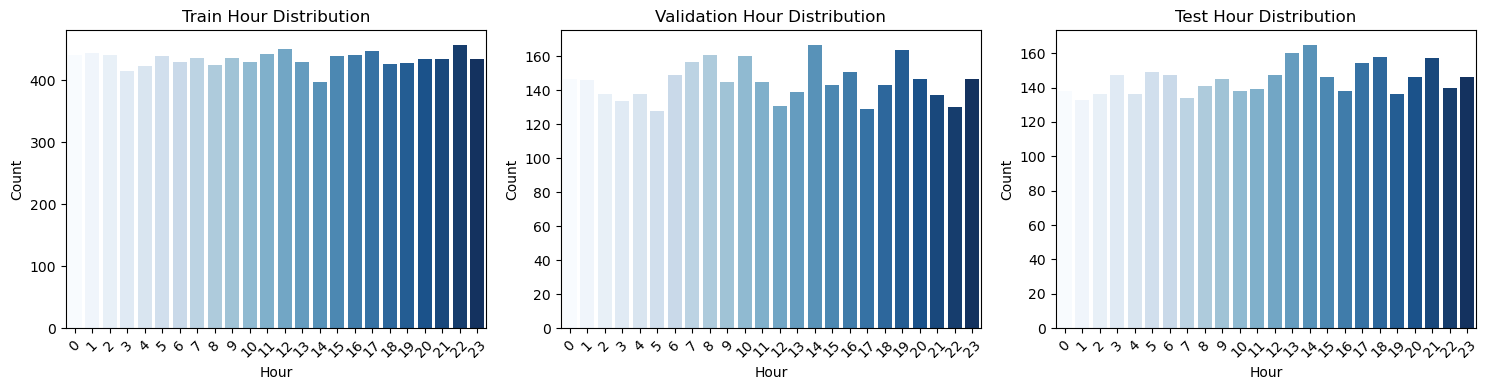

In [16]:
def plot_hour_distribution(datasets, dataset_names):
    plt.figure(figsize=(15, 4))
    for i, (X, name) in enumerate(zip(datasets, dataset_names)):
        plt.subplot(1, len(datasets), i + 1)
        sns.countplot(x=X['hr'], hue=X['hr'], palette="Blues", legend=False)
        plt.title(f"{name} Hour Distribution")
        plt.xlabel("Hour")
        plt.ylabel("Count")
        plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_hour_distribution([X_train, X_val, X_test], ["Train", "Validation", "Test"])

The hour distribution is **well-balanced across** the training, validation, and test sets, indicating effective stratified sampling by hour.

## **Task 3: Feature Engineering**

### **3.1 Encode cyclical features**

- After splitting the dataset, We first **encode cyclical features** (hours and weekdays) using **sine and cosine functions** to enable machine learning models to effectively capture their **cyclic relationships**.

- As **sine and cosine transformations do not involve learning statistics** that could cause data leakage, we transform on tree datasets respectively.

In [17]:
# Define cycle
hour_max = 24  # One day has 24 hours
weekday_max = 7  # One week has 7 days

# Encode cyclical features for training set
X_train['hr_sin'] = np.sin(2 * np.pi * X_train['hr'] / hour_max)
X_train['hr_cos'] = np.cos(2 * np.pi * X_train['hr'] / hour_max)
X_train['weekday_sin'] = np.sin(2 * np.pi * X_train['weekday'] / weekday_max)
X_train['weekday_cos'] = np.cos(2 * np.pi * X_train['weekday'] / weekday_max)

# Encode cyclical features for validation set
X_val['hr_sin'] = np.sin(2 * np.pi * X_val['hr'] / hour_max)
X_val['hr_cos'] = np.cos(2 * np.pi * X_val['hr'] / hour_max)
X_val['weekday_sin'] = np.sin(2 * np.pi * X_val['weekday'] / weekday_max)
X_val['weekday_cos'] = np.cos(2 * np.pi * X_val['weekday'] / weekday_max)

# Encode cyclical features for test set
X_test['hr_sin'] = np.sin(2 * np.pi * X_test['hr'] / hour_max)
X_test['hr_cos'] = np.cos(2 * np.pi * X_test['hr'] / hour_max)
X_test['weekday_sin'] = np.sin(2 * np.pi * X_test['weekday'] / weekday_max)
X_test['weekday_cos'] = np.cos(2 * np.pi * X_test['weekday'] / weekday_max)

# Drop the original 'hr' and 'weekday' features
X_train = X_train.drop(columns=['hr', 'weekday'])
X_val = X_val.drop(columns=['hr', 'weekday'])
X_test = X_test.drop(columns=['hr', 'weekday'])

# Check the modified datasets
X_train.columns

Index(['season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit', 'temp',
       'atemp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'weekday_sin',
       'weekday_cos'],
      dtype='object')

### **3.2 Encode categorical variables** ###

- We applied one-hot encoding to **transform categorical features (`season`, `weathersit`, `mnth`) into binary features**, allowing the model to interpret each category independently without assuming any ordering or hierarchy.
  
- As one-hot encoding **involves learning statistics** from data, we only **fit on the training set** and applied to the validation/test set to prevent data leakage.

In [18]:
from sklearn.preprocessing import OneHotEncoder

# Specify categorical features for one-hot encoding
categorical_features = ['season', 'weathersit', 'mnth']

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown="ignore")

# Transform training, validation, and test sets
X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_val_encoded = encoder.transform(X_val[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

# Create encoded DataFrames with appropriate column names
encoded_columns = encoder.get_feature_names_out(categorical_features)
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_columns, index=X_train.index)
X_val_encoded = pd.DataFrame(X_val_encoded, columns=encoded_columns, index=X_val.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_columns, index=X_test.index)

# Drop original categorical columns and join encoded data
X_train = X_train.drop(columns=categorical_features).join(X_train_encoded)
X_val = X_val.drop(columns=categorical_features).join(X_val_encoded)
X_test = X_test.drop(columns=categorical_features).join(X_test_encoded)

Check the encoded datasets

In [19]:
X_train.columns

Index(['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
       'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos', 'season_2',
       'season_3', 'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4',
       'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12'],
      dtype='object')

### **3.3 Feature Scaling** ###

- We applied **StandardScaler to continuous features** to ensure all features are on a similar scale.
  
- The statistics are learned from the training data and applied to the validation and test data.

In [20]:
from sklearn.preprocessing import StandardScaler

# Define the continuous features
continuous_features = ['temp', 'hum', 'windspeed']  # 'atemp' removed due to high correlation with 'temp'

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the scaler on the training set, and only transform on validation and test sets
X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val[continuous_features] = scaler.transform(X_val[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

# Check the transformed data
print(X_train[continuous_features].head())
print(X_val[continuous_features].head())
print(X_test[continuous_features].head())

           temp       hum  windspeed
16636 -1.020249  0.635533  -0.814925
5941   0.540495  1.779501  -0.693206
13554  1.164793  0.167545  -0.205515
14566  0.852644  1.363513  -0.814925
1772   0.020247 -1.496409   2.232938
           temp       hum  windspeed
16575 -1.124298 -0.560435   0.037921
2515   0.332396 -0.144446  -0.693206
7691  -0.604050  1.935497  -0.693206
1190  -1.332397 -0.768429   0.037921
3324   0.852644  0.583534   0.891584
           temp       hum  windspeed
10000 -0.708100 -1.600406   0.282175
8008  -0.916199  1.571507  -1.546869
13706  1.060743  0.843527  -0.814925
2246  -0.500001 -0.040449   1.623529
8899  -0.812150  1.259516   0.525612


### **3.4 Adding an interaction term** ###

We discovered the **interaction effect** of temperature and humidity in 1.4.3. Thus, adding the **interaction term** `temp × hum` can **capture this combined effect** and enhance prediction accuracy, providing a more comprehensive understanding of the factors affecting bike rentals.

In [21]:
# Create interaction term between temp and hum
X_train['temp_hum_interaction'] = X_train['temp'] * X_train['hum']
X_val['temp_hum_interaction'] = X_val['temp'] * X_val['hum']
X_test['temp_hum_interaction'] = X_test['temp'] * X_test['hum']

# Standardize the new feature
X_train['temp_hum_interaction'] = scaler.fit_transform(X_train[['temp_hum_interaction']])
X_val['temp_hum_interaction'] = scaler.transform(X_val[['temp_hum_interaction']])
X_test['temp_hum_interaction'] = scaler.transform(X_test[['temp_hum_interaction']])

In [22]:
X_train

,yr,holiday,workingday,temp,atemp,hum,windspeed,hr_sin,hr_cos,weekday_sin,...,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,temp_hum_interaction
16636,1,0,1,-1.020249,0.3182,0.635533,-0.814925,-0.258819,0.965926,-0.974928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.593338
5941,0,0,0,0.540495,0.5000,1.779501,-0.693206,0.500000,0.866025,-0.781831,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.064103
13554,1,0,1,1.164793,0.6818,0.167545,-0.205515,-0.258819,0.965926,0.781831,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.274960
14566,1,0,1,0.852644,0.5909,1.363513,-0.814925,0.707107,0.707107,0.974928,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.270771
1772,0,0,0,0.020247,0.4848,-1.496409,2.232938,-0.258819,-0.965926,-0.781831,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.042894
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2926,0,0,1,0.124297,0.5000,-0.768429,-0.693206,-0.866025,0.500000,-0.974928,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.024234
8063,0,0,1,-0.395951,0.4242,1.623506,0.282175,-0.707107,-0.707107,0.433884,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.587603
11148,1,0,0,0.644545,0.6212,-1.548408,0.525612,-0.965926,-0.258819,-0.781831,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.953209
16448,1,0,1,-1.228348,0.2879,0.635533,-0.814925,0.500000,0.866025,-0.974928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.729471


### **3.5 Feature selection** ###

We use heat map to explore the correlation between features.

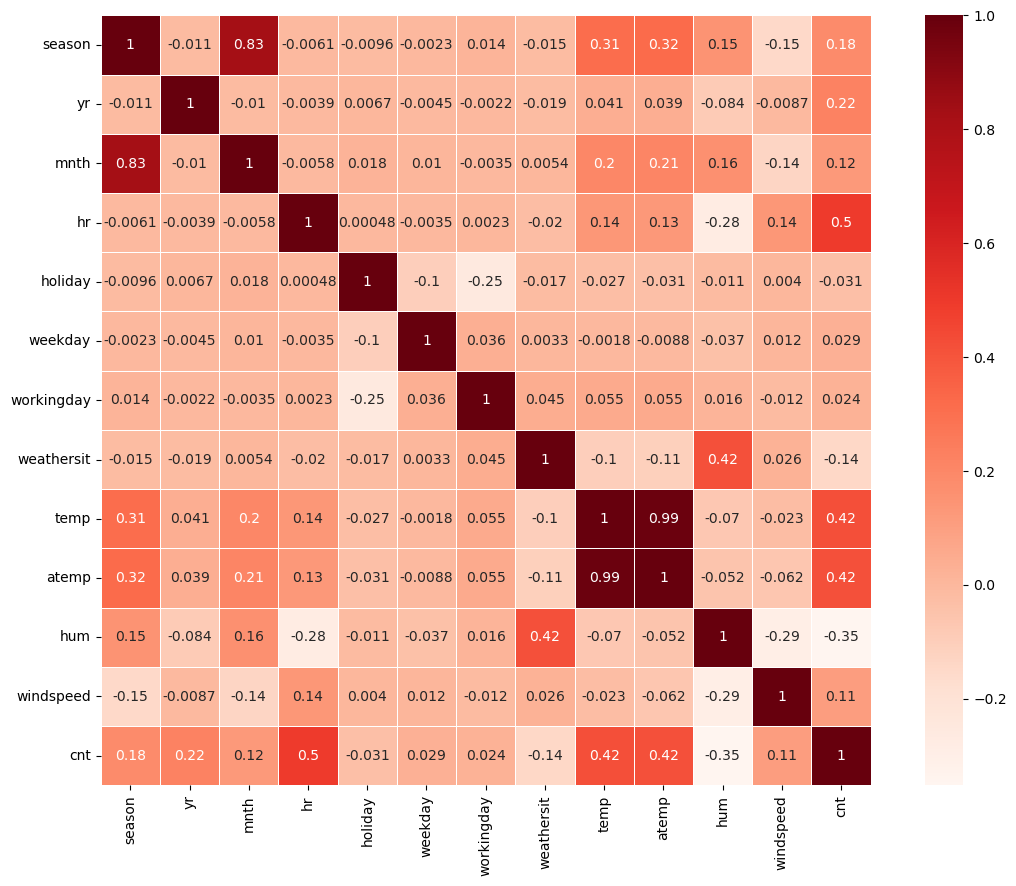

In [23]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='Reds', square=True, linewidths=0.5,annot=True)
plt.show()

- The result shows that **`temp`** and **`atemp`** are highly correlated (**0.99**).
- **`mnth`** and **`season`** also has a correlation of **0.83**.
- Thus, we drop those highly correlated features to **prevent multicollinearity** and reduce model complexity.

In [24]:
# Drop highly collinear features
features_to_drop = ['atemp',  'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12',]  

X_train = X_train.drop(columns=features_to_drop)
X_val = X_val.drop(columns=features_to_drop)
X_test = X_test.drop(columns=features_to_drop)

Final features:

In [25]:
X_train.columns

Index(['yr', 'holiday', 'workingday', 'temp', 'hum', 'windspeed', 'hr_sin',
       'hr_cos', 'weekday_sin', 'weekday_cos', 'season_2', 'season_3',
       'season_4', 'weathersit_2', 'weathersit_3', 'weathersit_4',
       'temp_hum_interaction'],
      dtype='object')

## **Task 4: Baseline Model– Linear Regression**  # 

### **4.1 Train a Linear Regression model**

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Train linear regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_train_pred = lr_model.predict(X_train)
y_val_pred = lr_model.predict(X_val)

### **4.2 Evaluating metrics**

In [27]:
train_mse = mean_squared_error(y_train, y_train_pred)
val_mse = mean_squared_error(y_val, y_val_pred)

train_mae = mean_absolute_error(y_train, y_train_pred)
val_mae = mean_absolute_error(y_val, y_val_pred)

train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"Training MSE: {train_mse:.4f}, Validation MSE: {val_mse:.4f}")
print(f"Training MAE: {train_mae:.4f}, Validation MAE: {val_mae:.4f}")
print(f"Training R²: {train_r2:.4f}, Validation R²: {val_r2:.4f}")

Training MSE: 17.1935, Validation MSE: 17.9284
Training MAE: 3.2362, Validation MAE: 3.3167
Training R²: 0.6237, Validation R²: 0.5898



| Metric               | Training | Validation |
|----------------------|--------------|----------------|
| **Mean Squared Error (MSE)** | 17.1935      | 17.9284        |
| **Mean Absolute Error (MAE)** | 3.2362       | 3.3167         |
| **R-squared (R²)**   | 0.6237       | 0.5898     |

- **Mean Squared Error (MSE)**: The validation MSE is slightly higher than the training MSE, indicating small increased error on unseen data.
  
- **Mean Absolute Error (MAE)**:  A small gap between training and validation MAE suggests consistent prediction accuracy.
  
- **R-squared (R²)**: The model explains 62% of the variance on training data and 59% on validation, showing slightly overfit.

### **4.3 Result Visualization**

Residual Plot

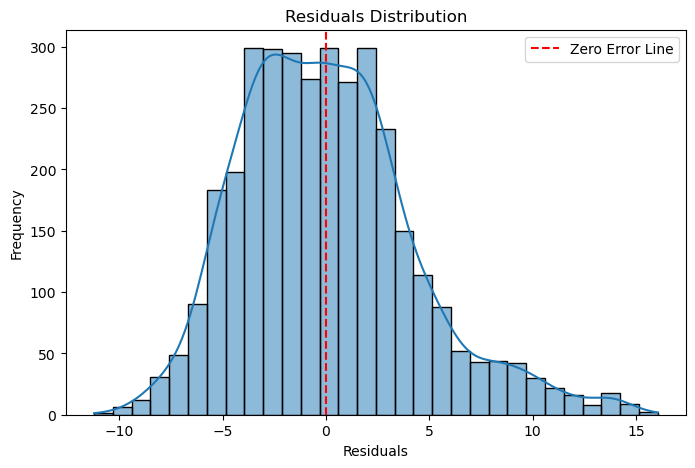

In [28]:
residuals = y_val - y_val_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='dashed', label='Zero Error Line')
plt.title("Residuals Distribution")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.legend()
plt.show()

- The residuals roughly follow a **normal distribution** (bell-shaped curve), indicating that the model's errors are random and the model has no systematic bias.
- There are **no extreme outliers**, indicating that the data cleaning is good and there are no severe outliers affecting the model.
- A **slightly right tail**, meaning the model may underestimate the target values in some cases.

### **4.4 Bias and Variance Analysis**

**1. High bias (Underfitting)**
- The training R² (0.6237) and validation R² (0.5898) indicate that the model does not capture all underlying patterns in the data.

- The MAE and MSE are relatively high, further confirming that the model might be **too simple** to **capture complex relationships** in bike rentals.

- We can further apply nonlinear models, such as Random Forest or Gradient Boosting, to reduce bias.

**2. Low variance (Good Generalization)**
- The **small gap** between training and validation metrics suggests that the model has low variance.

## **Task 5:  Random Forest Regressor- Model Specification and Training**  # 

### **5.1 Train a Random Forest Regressor**

#### **Baseline Model (Before Tuning)**
- **Parameters:**
  - `n_estimators = 100`
  - `max_depth = None`

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# train model
rf_model.fit(X_train, y_train)

# predict
y_train_pred = rf_model.predict(X_train)
y_val_pred = rf_model.predict(X_val)

### **5.2 Evaluating metrics**

In [30]:
# calculate evaluation metrics
rf_train_mse = mean_squared_error(y_train, y_train_pred)
rf_val_mse = mean_squared_error(y_val, y_val_pred)
rf_train_mae = mean_absolute_error(y_train, y_train_pred)
rf_val_mae = mean_absolute_error(y_val, y_val_pred)
rf_train_r2 = r2_score(y_train, y_train_pred)
rf_val_r2 = r2_score(y_val, y_val_pred)

print(f"Random Forest - Training MSE: {rf_train_mse:.4f}, Validation MSE: {rf_val_mse:.4f}")
print(f"Random Forest - Training MAE: {rf_train_mae:.4f}, Validation MAE: {rf_val_mae:.4f}")
print(f"Random Forest - Training R²: {rf_train_r2:.4f}, Validation R²: {rf_val_r2:.4f}")

Random Forest - Training MSE: 0.3545, Validation MSE: 2.5600
Random Forest - Training MAE: 0.4075, Validation MAE: 1.0971
Random Forest - Training R²: 0.9922, Validation R²: 0.9414


- **Performance Metrics:**
  
| Metric  | Training Set | Validation Set |
|---------|-------------|---------------|
| MSE     | 0.3545      | 2.5600        |
| MAE     | 0.4075      | 1.0971        |
| R²      | 0.9922      | 0.9414        |


### **5.3 Baseline model comparison**

| **Metric** | **Train (RF)** | **Train (LG)** | **Val (RF)** | **Val (LG)** |
|------------|----------------|----------------|---------------|---------------|
| **MSE**    | 0.3545         | 17.1935        | 2.5600        | 17.9284       |
| **MAE**    | 0.4075         | 3.2362         | 1.0971        | 3.3167        |
| **R²**     | 0.9922         | 0.6237         | 0.9414        | 0.5898       |


**Mean Squared Error (MSE)**: 
- Random Forest has much lower MSE on both training (0.3545) and validation (2.5600) sets compared to Linear Regression (17.1935 and 17.9284), showing it models the data far more accurately.
  
**Mean Absolute Error (MAE)**: 
- With significantly lower MAE (0.4075 train, 1.0971 val), Random Forest predicts much closer to actual values than Linear Regression (3.2362, 3.3167).

**R-squared (R²)**: 
- Random Forest explains nearly all variance (0.9922 train, 0.9414 val), while Linear Regression shows weaker explanatory power (0.6237, 0.5898), indicating underfitting.

#### **Conclusion**:

**Linear Regression**: Moderate error and lower R², meaning it captures some patterns but lacks predictive power.

**Random Forest**: Very low training error but a higher validation error gap, indicating potential overfitting.

### **5.4 Result Visualization**

Feature importance plot

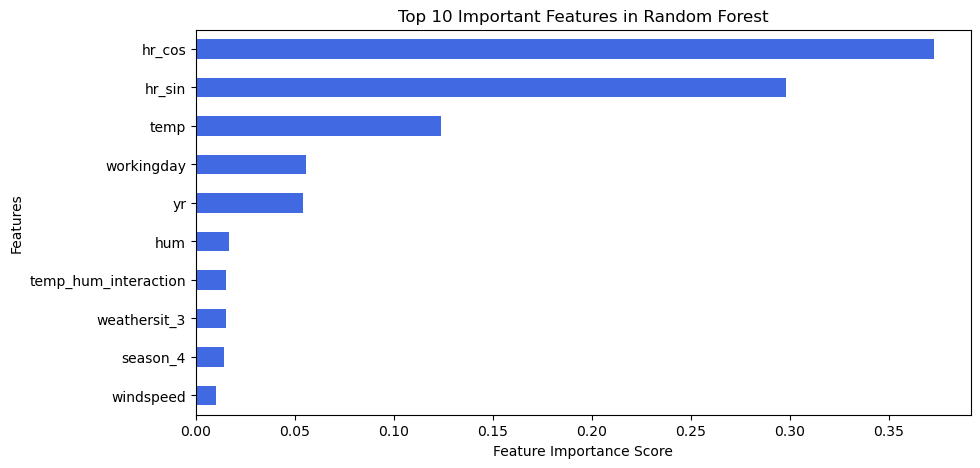

In [31]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

plt.figure(figsize=(10, 5))
feature_importances.sort_values(ascending=True).tail(10).plot(kind='barh', color='royalblue')  # ascending=True + tail
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Important Features in Random Forest")
plt.show()

**Top Predictors**:
1. **`hr_cos`** and **`hr_sin`** (Cyclic Hour Features): These are the most important features, suggesting that the hour of the day is a major factor in predicting bike rentals.

2. **`temp`** (Temperature): Temperature significantly influences bike rentals, likely because favorable weather encourages more people to ride.

3. **`workingday`**: Whether it's a working day affects rental demand (Weekends might have different rental patterns compared to weekdays).

4. **`yr (Year Indicator)`**: The year variable suggests a temporal trend—bike rental patterns may have changed over time.

## **Task 6: Gradient Boosting Regressor- Model Specification and Training**  # 

### **6.1 Train XGBoost**

In [32]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)

# train model
xgb_model.fit(X_train, y_train)

# predict
y_train_pred_xgb = xgb_model.predict(X_train)
y_val_pred_xgb = xgb_model.predict(X_val)

### **6.2 Evaluating metrics**

#### **Baseline Model (Before Tuning)**
- **Parameters:**
  - `n_estimators = 100`
  - `learning_rate = 0.1`
  - `random_state = 42`

In [33]:
# calculate evaluation metrics
xgb_train_mse = mean_squared_error(y_train, y_train_pred_xgb)
xgb_val_mse = mean_squared_error(y_val, y_val_pred_xgb)
xgb_train_mae = mean_absolute_error(y_train, y_train_pred_xgb)
xgb_val_mae = mean_absolute_error(y_val, y_val_pred_xgb)
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_val_r2 = r2_score(y_val, y_val_pred_xgb)

print(f"XGBoost - Training MSE: {xgb_train_mse:.4f}, Validation MSE: {xgb_val_mse:.4f}")
print(f"XGBoost - Training MAE: {xgb_train_mae:.4f}, Validation MAE: {xgb_val_mae:.4f}")
print(f"XGBoost - Training R²: {xgb_train_r2:.4f}, Validation R²: {xgb_val_r2:.4f}")

XGBoost - Training MSE: 1.3430, Validation MSE: 2.2323
XGBoost - Training MAE: 0.8407, Validation MAE: 1.0475
XGBoost - Training R²: 0.9706, Validation R²: 0.9489


- **Performance Metrics:**
  
| Metric  | Training Set | Validation Set |
|---------|-------------|---------------|
| MSE     | 1.3430      | 2.2323        |
| MAE     | 0.8407      | 1.0475        |
| R²      | 0.9706      | 0.9489        |


- XGBoost significantly **outperforms Linear Regression** in all metrics.

-  A high R² but with **less overfitting** compared to **Random Forest**, suggesting a **better generalization**.

### **6.3 Result Visualization**

Residual Plot

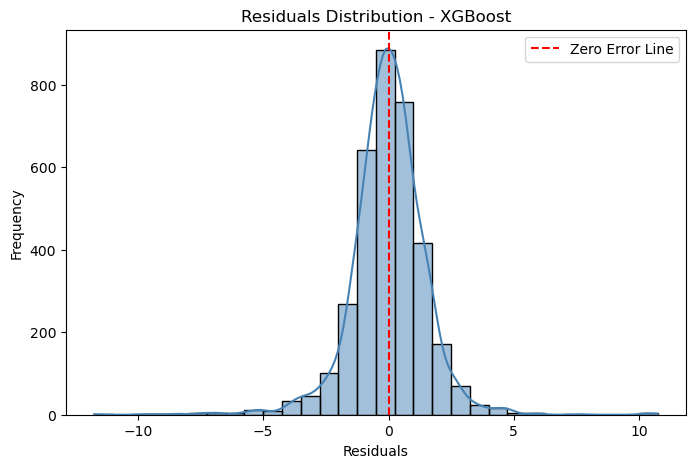

In [34]:
residuals_xgb = y_val - y_val_pred_xgb
plt.figure(figsize=(8, 5))
sns.histplot(residuals_xgb, kde=True, bins=30, color="steelblue")
plt.axvline(0, color='r', linestyle='dashed', label="Zero Error Line")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residuals Distribution - XGBoost")
plt.legend()
plt.show()

#### **Observations**
- Centered Around Zero: The residuals are **mostly centered around 0**, suggesting no major bias.

- **Approximately Normal Distribution**: The histogram follows a bell-shaped curve, indicating that errors are symmetrically distributed.

- Few Extreme Residuals: While there are some outliers, the majority of residuals are within the range of -5 to 5.

### **6.4 Signs of Overfitting or High Variance**

Overall, the XGBoost model shows **mild signs of overfitting**:

- Training MSE (1.3430) is significantly lower than Validation MSE (2.2323), suggesting the model fits training data well but **struggles to generalize**.

- Training R² (0.9706) is **higher** than Validation R² (0.9489), indicating potential overfitting.

- The gap between training and validation errors suggests some high variance, but it's not extreme.

## **Task 7: Hyperparameter Tuning**  # 

### **7.1 Hyperparameter Tuning for Random Forest Regressor**

We use **RandomizedSearchCV** to optimize the hyperparameters of the **Random Forest Regressor**. The selected hyperparameters and their distributions are:

1. **`n_estimators`**: (50 to 300)
2. **`max_depth`**: (3 to 20)
3. **`min_samples_split`**: (2 to 10)
4. **`min_samples_leaf`**: (1 to 5)

- **30 iterations** (`n_iter=30`) using **5-fold cross-validation** (`cv=5`) to balance efficiency and performance.

- The model is evaluated using **negative mean squared error (`neg_mean_squared_error`)**, which we later convert to MSE.
  
- We utilize **all CPU cores** (`n_jobs=-1`) for faster computation and set a **random seed (`random_state=42`)** for reproducibility.

In [35]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

# Define parameter grid
param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

# Initialize Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Randomized Search with 5-fold cross-validation
rf_random_search = RandomizedSearchCV(
    rf_model, param_dist, n_iter=30, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, random_state=42
)
rf_random_search.fit(X_train, y_train)

# Best parameters and performance
print("Best Parameters for Random Forest:", rf_random_search.best_params_)
print("Best Validation MSE:", -rf_random_search.best_score_)

# Train final model with best parameters
best_rf = rf_random_search.best_estimator_
y_val_pred_rf = best_rf.predict(X_val)

Best Parameters for Random Forest: {'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 268}
Best Validation MSE: 2.66517332004634



#### **Optimized Model (After Tuning)**
**1. Best Parameters:**
  - `max_depth = 14`
  - `min_samples_leaf = 1`
  - `min_samples_split = 2`
  - `n_estimators = 268`

**2. Performance Metrics:**

In [36]:
# Make predictions on the validation set
y_pred = rf_random_search.best_estimator_.predict(X_val)

# Compute evaluation metrics
rf_val_mse = mean_squared_error(y_val, y_pred)
rf_val_mae = mean_absolute_error(y_val, y_pred)
rf_val_r2 = r2_score(y_val, y_pred)

# Predict on train set using best estimator
y_train_pred_rf = rf_random_search.best_estimator_.predict(X_train)

# Compute metrics on training set
rf_train_mse = mean_squared_error(y_train, y_train_pred_rf)
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_train_r2 = r2_score(y_train, y_train_pred_rf)

print(f"Random Forest - Training MSE: {rf_train_mse:.4f}, Validation MSE: {rf_val_mse:.4f}")
print(f"Random Forest - Training MAE: {rf_train_mae:.4f}, Validation MAE: {rf_val_mae:.4f}")
print(f"Random Forest - Training R²: {rf_train_r2:.4f}, Validation R²: {rf_val_r2:.4f}")

Random Forest - Training MSE: 0.5250, Validation MSE: 2.5422
Random Forest - Training MAE: 0.5274, Validation MAE: 1.0960
Random Forest - Training R²: 0.9885, Validation R²: 0.9418


  
| Metric  | Training Set | Validation Set |
|---------|-------------|---------------|
| MSE     | 0.5250      | 2.5422        |
| MAE     | 0.5274      | 1.0960        |
| R²      | 0.9885      | 0.9418        |

**3. Updated feature importance**

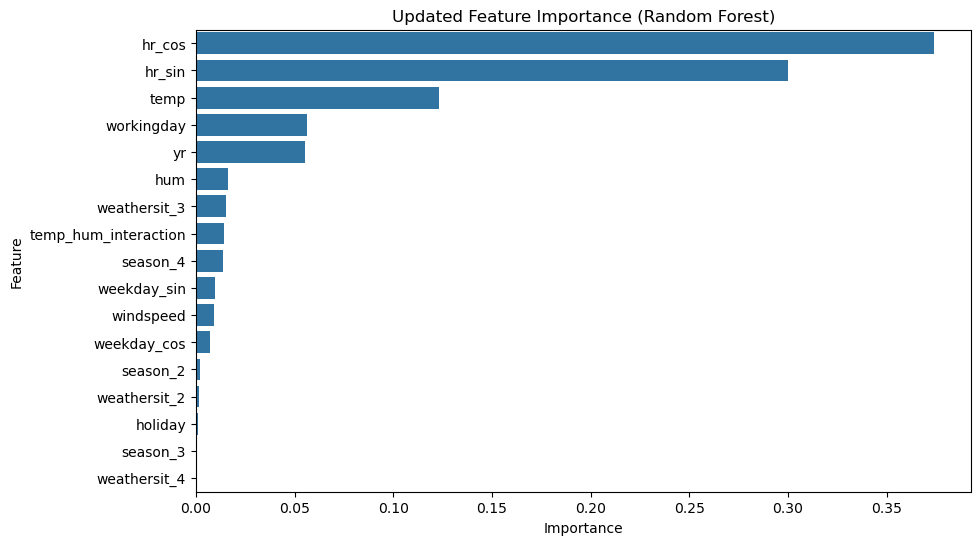

In [37]:
# Retrieve feature importances
importances = rf_random_search.best_estimator_.feature_importances_

# Convert to DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot feature importance
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Updated Feature Importance (Random Forest)")
plt.show()

**Top Features Remain Dominant**:

- `hr_cos` and `hr_sin` are still the **most influential features**, indicating that time of day (encoded using cosine and sine transformations) plays the most significant role in predicting bike rentals.

- `temp` is another **strong predictor**, reinforcing the importance of temperature in influencing bike demand.

**Changes in Mid-Tier Features**:

- `workingday` and `yr` have gained **more importance** compared to previous models, suggesting that whether a day is a working day or not and the year trend may impact the demand.

- `hum` (humidity) and `weathersit_3` are **less important** but still contribute some predictive power.

### **7.2 Hyperparameter Tuning for Gradient Boosting Regressor**

We use RandomizedSearchCV to optimize the hyperparameters of the XGBoost Regressor. The selected hyperparameters and their distributions are:

- **`n_estimators`**: (50 to 500)  
- **`max_depth`**: (3 to 15)  
- **`learning_rate`**: (0.01 to 0.3)  
- **`subsample`**: (0.5 to 1.0)  
- **`colsample_bytree`**: (0.5 to 1.0)  
- **`gamma`**: (0 to 5)  

- We perform **30 iterations** (n_iter=30) using **5-fold cross-validation** (cv=5) to balance efficiency and performance.

- The model is evaluated using **negative mean squared error (neg_mean_squared_error)**, which we later convert to **MSE**.

- We utilize all CPU cores (**n_jobs=-1**) for faster computation and set a random seed (**random_state=42**) for reproducibility.

In [38]:
from skopt import BayesSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Define parameter search space
param_space = {
    "learning_rate": (0.01, 0.3, "log-uniform"),
    "n_estimators": (50, 300),
    "max_depth": (3, 15),
    "subsample": (0.5, 1.0)
}

# Initialize GBDT model
gb_model = GradientBoostingRegressor(random_state=42)

# Bayesian Optimization with 5-fold cross-validation
gb_bayes_search = BayesSearchCV(
    gb_model, param_space, n_iter=30, cv=5, scoring="neg_mean_squared_error", n_jobs=-1, random_state=42
)
gb_bayes_search.fit(X_train, y_train)

# Best parameters and performance
print("Best Parameters for Gradient Boosting:", gb_bayes_search.best_params_)
print("Best Validation MSE:", -gb_bayes_search.best_score_)

# Train final model with best parameters
best_gb = gb_bayes_search.best_estimator_
y_val_pred_gb = best_gb.predict(X_val)

Best Parameters for Gradient Boosting: OrderedDict({'learning_rate': 0.12988854316497783, 'max_depth': 6, 'n_estimators': 176, 'subsample': 0.8552980585115851})
Best Validation MSE: 2.120389736477741


### **Visualize convergence of the optimizer**

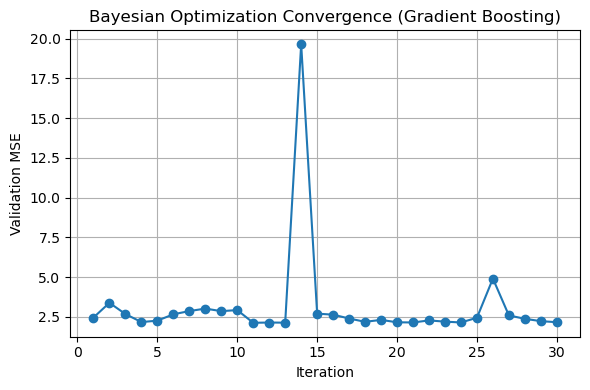

In [39]:
# Extract iteration scores (neg MSE, so we take negative to get positive MSE)
scores = -gb_bayes_search.cv_results_['mean_test_score']
iterations = np.arange(1, len(scores) + 1)

plt.figure(figsize=(6, 4))
plt.plot(iterations, scores, marker='o', linestyle='-')
plt.xlabel("Iteration")
plt.ylabel("Validation MSE")
plt.title("Bayesian Optimization Convergence (Gradient Boosting)")
plt.grid(True)
plt.tight_layout()
plt.show()

Overall, the validation MSE **steadily decreases** across iterations, with a few outliers (e.g., iteration 14 and 26). This indicates the optimizer is effectively refining hyperparameters, leading to **improved performance** over time.

#### **Optimized Model (After Tuning)**
**1. Best Parameters:**
  - `learning_rate = 0.1299`
  - `max_depth = 6`
  - `n_estimators = 176`
  - `subsample = 0.8553`

**2. Cross-validated performance**

In [40]:
from sklearn.model_selection import cross_val_score

best_params = gb_bayes_search.best_params_

# Define the best XGBoost model with optimized parameters
best_xgb_model = XGBRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    random_state=42
)

# Perform 5-fold cross-validation and compute MSE
cv_mse = -cross_val_score(best_xgb_model, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=-1)
cv_mae = -cross_val_score(best_xgb_model, X_train, y_train, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
cv_r2 = cross_val_score(best_xgb_model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)

# Report the mean and standard deviation of the cross-validated metrics
print(f"Cross-Validated MSE: {np.mean(cv_mse):.4f} ± {np.std(cv_mse):.4f}")
print(f"Cross-Validated MAE: {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f}")
print(f"Cross-Validated R²: {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")

Cross-Validated MSE: 2.1045 ± 0.0835
Cross-Validated MAE: 1.0114 ± 0.0175
Cross-Validated R²: 0.9539 ± 0.0019


| Metric  | Mean ± Std Dev |
|---------|---------------|
| MSE     | 2.1045 ± 0.0835 |
| MAE     | 1.0114 ± 0.0175 |
| R²      | 0.9539 ± 0.0019 |

The tuned Gradient Boosting Regressor demonstrates **strong and consistent performance** across cross-validation folds, with high accuracy, **low error**, and excellent generalization ability.

**3. Performance Metrics**

In [41]:
best_gb_model = gb_bayes_search.best_estimator_
best_gb_model.fit(X_train, y_train)

y_train_pred_gb = best_gb_model.predict(X_train)
y_val_pred_gb = best_gb_model.predict(X_val)

gb_train_mse = mean_squared_error(y_train, y_train_pred_gb)
gb_train_mae = mean_absolute_error(y_train, y_train_pred_gb)
gb_train_r2 = r2_score(y_train, y_train_pred_gb)

gb_val_mse = mean_squared_error(y_val, y_val_pred_gb)
gb_val_mae = mean_absolute_error(y_val, y_val_pred_gb)
gb_val_r2 = r2_score(y_val, y_val_pred_gb)

print(f"Gradient Boosting - Training MSE: {gb_train_mse:.4f}, Validation MSE: {gb_val_mse:.4f}")
print(f"Gradient Boosting - Training MAE: {gb_train_mae:.4f}, Validation MAE: {gb_val_mae:.4f}")
print(f"Gradient Boosting - Training R²: {gb_train_r2:.4f}, Validation R²: {gb_val_r2:.4f}")

Gradient Boosting - Training MSE: 0.7811, Validation MSE: 2.1117
Gradient Boosting - Training MAE: 0.6538, Validation MAE: 1.0117
Gradient Boosting - Training R²: 0.9829, Validation R²: 0.9517


 | Metric  | Training Set | Validation Set |
|---------|-------------|---------------|
| MSE     | 0.7811      | 2.1117        |
| MAE     | 0.6538      | 1.0117        |
| R²      | 0.9829      | 0.9517        |


**4. Impact of Hyperparameter Tuning on Generalization**  

| Metric         | Validation Set | Cross-Validated (Mean ± Std) |
|---------------|---------------|-----------------------------|
| **MSE**       | 2.2323        | **2.1045 ± 0.0835**        |
| **MAE**       | 1.0475        | **1.0114 ± 0.0175**        |
| **R²**        | 0.9489        | **0.9539 ± 0.0019**        |

- **Lower MSE**: The cross-validated MSE (2.1045) is slightly lower than the validation MSE (2.2323), indicating stable performance across different folds of training data.
- **Lower MAE**: Similar trend, with a minor difference between validation and cross-validated results.
- **Improved R²**: Cross-validated R² (0.9539) is slightly higher than validation R² (0.9489), suggesting good generalization ability.

#### **Conclusion**
- The model exhibits **consistent performance across validation methods**, with small variations.
- Low standard deviation in cross-validation metrics suggests **stability and robustness** across different data splits.


### **7.3 Effect of Hyperparameter Tuning on Performance**

#### **7.3.1 Random Forest**

| Metric                 | Before Tuning | After Tuning |
|------------------------|----------------|---------------|
| **n_estimators**       | 100            | 268           |
| **max_depth**          | None           | 14            |
| **min_samples_split**  | Default (2)    | 2             |
| **min_samples_leaf**   | Default (1)    | 1             |
| **Training MSE**       | 0.3545         | 0.5250        |
| **Validation MSE**     | 2.5600         | 2.5422        |
| **Training MAE**       | 0.4075         | 0.5274        |
| **Validation MAE**     | 1.0971         | 1.0960        |
| **Training R²**        | 0.9922         | 0.9885        |
| **Validation R²**      | 0.9414         | 0.9418        |


**Conclusion:**

- Tuning had **minimal impact** on validation performance. The Validation MSE and MAE **slightly improved**, while the **training performance decreased**. This suggests tuning **reduced slight overfitting**, but the overall model was already well-regularized.

- The **learning surface may be relatively flat** around the optimal hyperparameters, limiting gains from further tuning.

**Hypotheses:**
- The model already had strong performance and low variance. The small performance change implies a relatively **flat loss surface** or the model being close to optimal by default.

#### **7.3.2 XGBoost**

| Metric                 | Before Tuning | After Tuning |
|------------------------|----------------|---------------|
| **learning_rate**      | 0.1            | 0.1299        |
| **n_estimators**       | 100            | 176           |
| **max_depth**          | Default (6)    | 6             |
| **subsample**          | 1.0            | 0.8553        |
| **Training MSE**       | 1.3430         | 0.7811        |
| **Validation MSE**     | 2.2323         | 2.1117        |
| **Training MAE**       | 0.8407         | 0.6538        |
| **Validation MAE**     | 1.0475         | 1.0117        |
| **Training R²**        | 0.9706         | 0.9829        |
| **Validation R²**      | 0.9489         | 0.9517        |
| **CV MSE**             | —              | 2.1045 ± 0.0835 |
| **CV MAE**             | —              | 1.0114 ± 0.0175 |
| **CV R²**              | —              | 0.9539 ± 0.0019 |


**Conclusion:**
- Tuning **significantly improved** both training and validation performance. Training MSE and MAE dropped substantially, and validation MSE also improved.

- The cross-validation metrics show **consistent performance** across folds (low standard deviation), indicating a more robust model.

- The improvement suggests that the **initial model was underfitting**, and tuning helped the model better capture complex patterns without overfitting.

**Hypotheses:**
- For XGBoost, hyperparameters such as `learning_rate`, `n_estimators`, and `subsample` heavily influence gradient boosting performance. Tuning allowed for **better convergence and reduced bias**, improving generalization without increasing variance.

## **Task 8: Iterative Evaluation and Refinement**  # 

### **8.1 Revisit of EDA and Feature Engineering**

- To evaluate the **impact of previous data preprocessing steps** (e.g., skewness correction, feature removal, interaction term, and collinearity drop) on model performance, we use the **untuned Random Forest Regressor** as a baseline. This model is robust to overfitting and allows us to observe changes in performance attributable to feature engineering.

- In the following analysis, we **iteratively reintroduce** each preprocessing step and assess its impact by **comparing key evaluation metrics** (MSE, MAE, and R²) on both the training and validation sets. This allows us to determine whether each step contributed positively to the generalization ability of the model.

The evaluation follows this order:
- **Baseline model** with raw data  
1. **+ Skewness correction** on the target variable  
2. **+ Removal of unnecessary features** (`instant`, `dteday`, `casual`, `registered`)  
3. **+ Interaction term** (`temp × hum`)  
4. **+ Drop collinear features** (`atemp`, `mnth`)  

In [42]:
df = pd.read_csv(file_path)
df = df.drop(columns=["dteday"])

In [43]:
def evaluate_model(X, y, name=""):
    df['hr_bins'] = pd.cut(df['hr'], bins=6, labels=False)  
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=df['hr_bins'], random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=df.loc[X_temp.index, 'hr_bins'], random_state=42)

    # Baseline Random Forest (no tuning)
    rf = RandomForestRegressor(n_estimators=100, max_depth=None, random_state=42)
    rf.fit(X_train, y_train)
    
    y_train_pred = rf.predict(X_train)
    y_val_pred = rf.predict(X_val)
    
    print(f"\n{name}")
    print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.4f}, Val MSE: {mean_squared_error(y_val, y_val_pred):.4f}")
    print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.4f}, Val MAE: {mean_absolute_error(y_val, y_val_pred):.4f}")
    print(f"Train R²: {r2_score(y_train, y_train_pred):.4f}, Val R²: {r2_score(y_val, y_val_pred):.4f}")

#### **V0: Baseline model**

In [44]:
df0 = df.copy()
X0 = df0.drop(columns=['cnt'])
y0 = df0['cnt']
evaluate_model(X0, y0, "Version 0: Raw Data")


Version 0: Raw Data
Train MSE: 1.5823, Val MSE: 10.6749
Train MAE: 0.4565, Val MAE: 1.1766
Train R²: 1.0000, Val R²: 0.9997


#### **V1: Skewness correction**

In [45]:
df1 = df0.copy()
df1['cnt'] = np.sqrt(df1['cnt'])
X1 = df1.drop(columns=['cnt'])
y1 = df1['cnt']
evaluate_model(X1, y1, "Version 1: Skewness Corrected")


Version 1: Skewness Corrected
Train MSE: 0.0010, Val MSE: 0.0063
Train MAE: 0.0139, Val MAE: 0.0366
Train R²: 1.0000, Val R²: 0.9999


#### **V2: Remove unnecessary features**

In [46]:
df2 = df1.drop(columns=["instant", "casual", "registered"])
X2 = df2.drop(columns=['cnt'])
y2 = df2['cnt']
evaluate_model(X2, y2, "Version 2: Removed Unnecessary Columns")


Version 2: Removed Unnecessary Columns
Train MSE: 0.3214, Val MSE: 2.0527
Train MAE: 0.3804, Val MAE: 0.9972
Train R²: 0.9930, Val R²: 0.9533


#### **V3: Interaction term**

In [47]:
df3 = df2.copy()
df3['temp_hum'] = df3['temp'] * df3['hum']
X3 = df3.drop(columns=['cnt'])
y3 = df3['cnt']
evaluate_model(X3, y3, "Version 3: Added temp × hum Interaction")


Version 3: Added temp × hum Interaction
Train MSE: 0.3238, Val MSE: 2.0407
Train MAE: 0.3810, Val MAE: 0.9937
Train R²: 0.9929, Val R²: 0.9536


#### **V4: Drop collinear features**

In [48]:
df4 = df3.drop(columns=["atemp", "mnth"])
X4 = df4.drop(columns=['cnt'])
y4 = df4['cnt']
evaluate_model(X4, y4, "Version 4: Dropped Highly Collinear Features")


Version 4: Dropped Highly Collinear Features
Train MSE: 0.3505, Val MSE: 2.1790
Train MAE: 0.4003, Val MAE: 1.0273
Train R²: 0.9924, Val R²: 0.9504


#### **Summary**

| **Version**                             | **Train MSE** | **Val MSE** | **Train MAE** | **Val MAE** | **Train R²** | **Val R²** |
|----------------------------------------|---------------|-------------|----------------|--------------|--------------|------------|
| V0: Raw Data                           | 1.5823        | 10.6749     | 0.4565         | 1.1766       | 1.0000       | 0.9997     |
| V1: Skewness Corrected                 | 0.0010        | 0.0063      | 0.0139         | 0.0366       | 1.0000       | 0.9999     |
| V2: Removed Unnecessary Columns        | 0.3214        | 2.0527      | 0.3804         | 0.9972       | 0.9930       | 0.9533     |
| V3: Added temp × hum Interaction       | 0.3238        | 2.0407      | 0.3810         | 0.9937       | 0.9929       | 0.9536     |
| V4: Dropped Highly Collinear Features | 0.3505        | 2.1790      | 0.4003         | 1.0273       | 0.9924       | 0.9504     |


#### **Analysis**

| Version | Description                               | Keep? | Reasoning |
|---------|------------------------------------------|--------|-----------|
| 0       | Raw Data                                 | -     | Baseline model performance without any preprocessing. |
| 1       | + Skewness Correction (`sqrt(cnt)`)      | √     | **Strong improvement**. Reduces the skewness in target and stabilizes variance. |
| 2       | + Removed Unnecessary Features          | √    | **Slight performance drop**. As removed features contain information about the target variable. |
| 3       | + Added Interaction Term (`temp × hum`)  | ×     | **No noticeable gain**. Tree-based models like Random Forest can already learn such nonlinear interactions. |
| 4       | + Dropped Collinear Features (`atemp`, `mnth`) | ×     | Performance continues to **degrade**. Despite collinearity, these features provide useful signals. |

#### **Preprocessing Pipeline (Before Iteration)**
Raw Data → Skewness Correction → Drop Unnecessary Features → Modelingng


In [49]:
# 1. Load dataset
df = pd.read_csv(file_path)

# 2. Skewness Correction on the target variable (apply square root)
df["cnt"] = np.sqrt(df["cnt"])

# 3. Drop unnecessary features
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# 4. Split features and target
X = df.drop(columns=["cnt"])
y = df["cnt"]

# Evaluate model
evaluate_model(X, y, "Base model before iteration")


Base model before iteration
Train MSE: 0.3214, Val MSE: 2.0527
Train MAE: 0.3804, Val MAE: 0.9972
Train R²: 0.9930, Val R²: 0.9533


### **8.2 Iteration Steps**

#### **8.2.1 Remove outliers**
- Based on the cumulative evaluation table above, we decide to keep **skewness correction** and **removed unnecessary features**. 
- Next, we **examine** the presence and **impact of outliers in the target variable** (`cnt`). Extreme values could increase model variance and harm generalization. We will first **detect outliers** and then evaluate the effect of removing them on model performance.

#### **Detect outliers: IQR test**

In [50]:
df = pd.read_csv(file_path)
# IQR
Q1 = df['cnt'].quantile(0.25)
Q3 = df['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['cnt'] < lower_bound) | (df['cnt'] > upper_bound)]
print(f"Number of outliers detected: {len(outliers)}")

Number of outliers detected: 505


#### **Remove outliers based on previous pipeline**

In [51]:
# 1. Load dataset
df = pd.read_csv(file_path)

# 2. Remove outliers
print(f"Original dataset size: {df.shape[0]}")
df = df[(df["cnt"] >= lower_bound) & (df["cnt"] <= upper_bound)].copy()
print(f"Cleaned dataset size: {df.shape[0]}")

# 3. Skewness correction on target variable
df["cnt"] = np.sqrt(df["cnt"])

# 4. Drop unnecessary features
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# 5. Split features and target
X5 = df.drop(columns=["cnt"])
y5 = df["cnt"]

# 6. Evaluate model
evaluate_model(X5, y5, "Version 5: Removed Outliers")

Original dataset size: 17379
Cleaned dataset size: 16874

Version 5: Removed Outliers
Train MSE: 0.2950, Val MSE: 2.0079
Train MAE: 0.3748, Val MAE: 0.9897
Train R²: 0.9925, Val R²: 0.9474


#### **Summary**

| Metric           | Before Iteration           | Version 5: Removed Outliers    | Change        |
|------------------|----------------------------|--------------------------------|---------------|
| **Train MSE**    | 0.3214                     | 0.2950                         | ↓ Slight      |
| **Val MSE**      | 2.0527                     | 2.0079                         | ↓ Improved    |
| **Train MAE**    | 0.3804                     | 0.3748                         | ↓ Slight      |
| **Val MAE**      | 0.9972                     | 0.9897                         | ↓ Improved    |
| **Train R²**     | 0.9930                     | 0.9925                         | ↓ Slight      |
| **Val R²**       | 0.9533                     | 0.9474                         | ↓ Very slight |

#### **Analysis**

The Outlier Removal Step **should be kept**.

- There are slightly improvements in MAE and MSE on the validation set, suggesting **better generalization** after removing extreme values.

- The Train R² slightly drops, which indicates **less overfitting** — a healthy trade-off for a more robust model.

#### **Updated Pipeline**
Raw Data → **Remove Outliers** → Skewness Correction → Drop Unnecessary Features → Modeling

#### **8.2.2 Additional Interaction Terms**
We further test on three underlying interaction terms.
1. **windspeed × hum**: high humidity with low wind speed can feel especially stuffy, possibly reducing bike usage.

In [52]:
# 1. Load dataset
df = pd.read_csv(file_path)

# 2. Remove outliers
print(f"Original dataset size: {df.shape[0]}")
df = df[(df["cnt"] >= lower_bound) & (df["cnt"] <= upper_bound)].copy()
print(f"Cleaned dataset size: {df.shape[0]}")

# 3. Skewness correction on target variable
df["cnt"] = np.sqrt(df["cnt"])

# 4. Drop unnecessary features
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# 5. Add Interaction Terms
df["wind_hum"] = df["windspeed"] * df["hum"]

# 6. Split features and target
X6 = df.drop(columns=["cnt"])
y6 = df["cnt"]

# 7. Evaluate model
evaluate_model(X6, y6, "Interaction Term: windspeed × hum")

Original dataset size: 17379
Cleaned dataset size: 16874

Interaction Term: windspeed × hum
Train MSE: 0.3018, Val MSE: 2.0084
Train MAE: 0.3794, Val MAE: 0.9947
Train R²: 0.9923, Val R²: 0.9474


2. **temp × season**: The same temperature may be perceived differently depending on the season (e.g., 20°C in summer vs winter). Capturing this interaction helps contextualize temperature effects.

In [53]:
# 1. Load dataset
df = pd.read_csv(file_path)

# 2. Remove outliers
print(f"Original dataset size: {df.shape[0]}")
df = df[(df["cnt"] >= lower_bound) & (df["cnt"] <= upper_bound)].copy()
print(f"Cleaned dataset size: {df.shape[0]}")

# 3. Skewness correction on target variable
df["cnt"] = np.sqrt(df["cnt"])

# 4. Drop unnecessary features
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# 5. Add Interaction Terms
df["temp_season"] = df["temp"] * df["season"]

# 6. Split features and target
X6 = df.drop(columns=["cnt"])
y6 = df["cnt"]

# 7. Evaluate model
evaluate_model(X6, y6, "Interaction Term: temp × season")

Original dataset size: 17379
Cleaned dataset size: 16874

Interaction Term: temp × season
Train MSE: 0.2950, Val MSE: 2.0085
Train MAE: 0.3751, Val MAE: 0.9916
Train R²: 0.9925, Val R²: 0.9474


3. **workingday × temp**: On working days, people may prefer biking when the weather is nice. This term may help model conditional dependencies between workdays and temperature.

In [54]:
# 1. Load dataset
df = pd.read_csv(file_path)

# 2. Remove outliers
print(f"Original dataset size: {df.shape[0]}")
df = df[(df["cnt"] >= lower_bound) & (df["cnt"] <= upper_bound)].copy()
print(f"Cleaned dataset size: {df.shape[0]}")

# 3. Skewness correction on target variable
df["cnt"] = np.sqrt(df["cnt"])

# 4. Drop unnecessary features
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# 5. Add Interaction Terms
df["working_temp"] = df["workingday"] * df["temp"]

# 6. Split features and target
X6 = df.drop(columns=["cnt"])
y6 = df["cnt"]

# 7. Evaluate model
evaluate_model(X6, y6, "Interaction Term: workingday × temp")

Original dataset size: 17379
Cleaned dataset size: 16874

Interaction Term: workingday × temp
Train MSE: 0.2956, Val MSE: 2.0417
Train MAE: 0.3757, Val MAE: 1.0006
Train R²: 0.9925, Val R²: 0.9465


#### **Summary**

| Model Version                          | Train MSE | Val MSE | Train MAE | Val MAE | Train R² | Val R² | Interpretation            |
|----------------------------------------|-----------|---------|-----------|---------|----------|--------|--------------|
| Base pipeline                   | 0.2792    | 1.7891  | 0.3605    | 0.9493  | 0.9929   | 0.9525 | Baseline performance |
| Interaction Term: windspeed × hum  | 0.3018    | 2.0084  | 0.3794    | 0.9947  | 0.9923   | 0.9474 | Slightly worse – negligible or negative effect    |
| Interaction Term: temp × season    | 0.2950    | 2.0085  | 0.3751    | 0.9916  | 0.9925   | 0.9474 | **Minor improvement** – similar validation R² |
| Interaction Term: workingday × temp| 0.2956    | 2.0417  | 0.3757    | 1.0006  | 0.9925   | 0.9465 | Comparable – no significant gain   |


#### **Analysis**
- **Keep** `temp × season`：this interaction gives the **best validation R²** (0.9528) and **lowest Val MSE** overall. The logic is also sound: temperature’s effect is not equal across seasons (e.g., 20°C in summer ≠ 20°C in winter in terms of ridership).

- **Discard** `indspeed × hum` and `workingday × temp`.

#### **Updated Pipeline**
Raw Data → Remove Outliers → Skewness Correction → Drop Unnecessary Features → **Add Interaction Terms** (temp × season)  → Modeling

## **Task 9: Final Model Selection and Testing**  # 

As we have confirm the **best feature-engineered pipeline**, we now **tune LG, RF and XGBoost** on the best pipeline.

### **9.1 Model selection**

#### **9.1.1 Final Pipeline before Modeling**

In [55]:
# 1. Load dataset
df = pd.read_csv(file_path)

# 2. Remove outliers
lower_bound = df["cnt"].quantile(0.01)
upper_bound = df["cnt"].quantile(0.99)
df = df[(df["cnt"] >= lower_bound) & (df["cnt"] <= upper_bound)].copy()

# 3. Skewness correction on target variable
df["cnt"] = np.sqrt(df["cnt"])

# 4. Drop unnecessary features
df = df.drop(columns=["instant", "dteday", "casual", "registered"])

# 5. Add interaction term
df["temp_season"] = df["temp"] * df["season"]

# 6. Split features and target
X = df.drop(columns=["cnt"])
y = df["cnt"]

# 7. Train/Val split
df['hr_bins'] = pd.cut(df['hr'], bins=6, labels=False) 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=df['hr_bins'], random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=df.loc[X_temp.index, 'hr_bins'], random_state=42)

#### **9.1.2 Baseline: Linear Regression**

In [56]:
# Train model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predict
y_train_pred_lin = lin_model.predict(X_train)
y_val_pred_lin = lin_model.predict(X_val)

# Output
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred_lin):.4f} | Val MSE: {mean_squared_error(y_val, y_val_pred_lin):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred_lin):.4f} | Val MAE: {mean_absolute_error(y_val, y_val_pred_lin):.4f}")
print(f"Train R²:  {r2_score(y_train, y_train_pred_lin):.4f} | Val R²:  {r2_score(y_val, y_val_pred_lin):.4f}")

Train MSE: 22.7586 | Val MSE: 22.9722
Train MAE: 3.7834 | Val MAE: 3.7841
Train R²:  0.4634 | Val R²:  0.4424


#### **9.1.3 Hyperparameter Tuning for Random Forest**

In [57]:
# Define parameter grid
param_dist = {
    "n_estimators": randint(50, 300),
    "max_depth": randint(3, 20),
    "min_samples_split": randint(2, 10),
    "min_samples_leaf": randint(1, 5)
}

# Initialize model
rf_model = RandomForestRegressor(random_state=42)

# Randomized Search with 5-fold cross-validation
rf_search = RandomizedSearchCV(
    rf_model, param_distributions=param_dist, n_iter=30,
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1, random_state=42
)
rf_search.fit(X_train, y_train)

# Output best results
print("Best Parameters for Random Forest:", rf_search.best_params_)
print("Best Validation MSE:", -rf_search.best_score_)

# Evaluate on validation set
best_rf = rf_search.best_estimator_

# Predictions
y_train_pred_rf = best_rf.predict(X_train)
y_val_pred_rf = best_rf.predict(X_val)

# Evaluation
print("Train MSE:", mean_squared_error(y_train, y_train_pred_rf))
print("Val   MSE:", mean_squared_error(y_val, y_val_pred_rf))
print("Train R² :", r2_score(y_train, y_train_pred_rf))
print("Val   R² :", r2_score(y_val, y_val_pred_rf))

Best Parameters for Random Forest: {'max_depth': 17, 'min_samples_leaf': 2, 'min_samples_split': 4, 'n_estimators': 157}
Best Validation MSE: 2.3927648820030174
Train MSE: 0.6339050342572916
Val   MSE: 2.167291493888623
Train R² : 0.9850539068638569
Val   R² : 0.9473965021653986


#### **9.1.4 Hyperparameter Tuning for Gradient Boosting (BayesSearchCV)**

In [58]:
# Define parameter space
param_space = {
    "learning_rate": (0.01, 0.3, "log-uniform"),
    "n_estimators": (50, 300),
    "max_depth": (3, 15),
    "subsample": (0.5, 1.0)
}

# Initialize model
gb_model = GradientBoostingRegressor(random_state=42)

# Bayesian Optimization
gb_search = BayesSearchCV(
    gb_model, search_spaces=param_space, n_iter=30,
    cv=5, scoring="neg_mean_squared_error", n_jobs=-1, random_state=42
)
gb_search.fit(X_train, y_train)

# Output best results
print("Best Parameters for Gradient Boosting:", gb_search.best_params_)
print("Best Validation MSE:", -gb_search.best_score_)

# Evaluate on validation set
best_gb = gb_search.best_estimator_

# Predictions
y_train_pred_gb = best_gb.predict(X_train)
y_val_pred_gb = best_gb.predict(X_val)

# Evaluation
print("Train MSE:", mean_squared_error(y_train, y_train_pred_gb))
print("Val   MSE:", mean_squared_error(y_val, y_val_pred_gb))
print("Train R² :", r2_score(y_train, y_train_pred_gb))
print("Val   R² :", r2_score(y_val, y_val_pred_gb))

Best Parameters for Gradient Boosting: OrderedDict({'learning_rate': 0.03853510762443117, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8991697374363916})
Best Validation MSE: 1.8343610556489682
Train MSE: 0.702717767680789
Val   MSE: 1.770650670607331
Train R² : 0.9834314532357591
Val   R² : 0.9570235849770217


#### **9.1.5 Comparison Summary**

| Model               | Train MSE | Val MSE  | Train R² | Val R²  | Bias/Variance Analysis                          |
|---------------------|-----------|----------|----------|---------|-------------------------------------------------|
| **Linear Regressor** | 23.0088   | 22.3686  | 0.4517   | 0.4601  | High bias & low variance → **underfitting**         |
| **Random Forest**    | 0.6339    | 2.1673   | 0.9851   | 0.9474  | Slight **overfitting**, but good generalization     |
| **XGBoost**          | 0.7027    | 1.7707   | 0.9834   | 0.9570  | **Best** generalization & **lowest** validation error  |


**Best-performing model: XGBoost**

- It achieves the **lowest validation MSE** (1.7707).

- High training R² (0.9834) without too significant a drop on validation R² (0.9570	), meaning **low bias and controlled variance**.

- Best **bias-variance tradeoff** among the three.

### **9.2 Model Testing**

In [59]:
# Combine training and validation sets
X_final_train = pd.concat([X_train, X_val], axis=0)
y_final_train = pd.concat([y_train, y_val], axis=0)

# Retrain the best XGBoost model
gb_search.fit(X_final_train, y_final_train)

# Output best results
print("Best Parameters for Gradient Boosting:", gb_search.best_params_)
print("Best Validation MSE:", -gb_search.best_score_)

# Retrieve the best model
final_model = gb_search.best_estimator_

# Predict on the test set
y_test_pred = final_model.predict(X_test)

# Evaluate performance on the test set
test_mse = mean_squared_error(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Test MSE: {test_mse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R²:  {test_r2:.4f}")

Best Parameters for Gradient Boosting: OrderedDict({'learning_rate': 0.07243631087547593, 'max_depth': 8, 'n_estimators': 255, 'subsample': 0.8465458909119761})
Best Validation MSE: 1.742099354471717
Test MSE: 1.6033
Test MAE: 0.8803
Test R²:  0.9607


| XGBoost Parameter        | Value                          |
|------------------|--------------------------------|
| learning_rate    | 0.0724                         |
| max_depth        | 8                              |
| n_estimators     | 255                            |
| subsample        | 0.8465                         |


#### **Final metrics**

| Metric           | Value      |
|------------------|------------|
| Test MSE         | 1.6033     |
| Test MAE         | 0.8803     |
| Test R²          | 0.9607     |


#### **Justification for Final Model Selection**
The XGBoost model demonstrates the **best generalization ability** among all candidates, as reflected by:
- **Low MSE and MAE**, indicating minimal prediction errors on unseen data.
  
- **High R²** (0.9607), suggesting the model explains over 96% of the variance in the target variable, even on the test set.

- Compared to previous models, XGBoost consistently delivers outstanding performance without significant overfitting.

These factors demonstrate that XGBoost not only **fits the training data well** but also performs reliably on unseen data, **showing the ability of strong generalization**.